In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"/Users/danilalipatov/Credit_Scoring_Model_w_transformers/data/Give_risks/GiveMeSomeCredit-training.csv").drop(columns=['Unnamed: 0'])

In [4]:
df.head(5)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [6]:
df.dtypes

SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

In [7]:
for col in df.columns:
    print(f"{col}, {df[col].unique()}")

SeriousDlqin2yrs, [1 0]
RevolvingUtilizationOfUnsecuredLines, [0.76612661 0.95715102 0.65818014 ... 0.29974515 0.24604392 0.85028295]
age, [ 45  40  38  30  49  74  57  39  27  51  46  76  64  78  53  43  25  32
  58  50  69  24  28  62  42  75  26  52  41  81  31  68  70  73  29  55
  35  72  60  67  36  56  37  66  83  34  44  48  61  80  47  59  77  63
  54  33  79  65  86  92  23  87  71  22  90  97  84  82  91  89  85  88
  21  93  96  99  94  95 101  98 103 102 107 105   0 109]
NumberOfTime30-59DaysPastDueNotWorse, [ 2  0  1  3  4  5  7 10  6 98 12  8  9 96 13 11]
DebtRatio, [0.80298213 0.1218762  0.08511338 ... 0.40429286 0.71656222 0.24990808]
MonthlyIncome, [ 9120.  2600.  3042. ... 15648.   521.  7647.]
NumberOfOpenCreditLinesAndLoans, [13  4  2  5  7  3  8  9  6 10 14 22 17  1 15 31 12 21 11 19 18 26 20 23
  0 16 27 29 28 24 25 32 46 33 30 34 37 38 36 35 54 43 45 49 57 48 40 58
 51 52 39 41 56 42 47 50 44 53]
NumberOfTimes90DaysLate, [ 0  1  3  2  5  4 98 10  9  6  7  8 15 9

In [8]:
ER = df["SeriousDlqin2yrs"].sum() / len(df)

In [9]:
ER

np.float64(0.06684)

Event Rate - доля положительных событий в выборке составляет всего 6,7% , что говорит о некотором дисбалансе и это надо учесть при обработке и подгатовке даных

Теперь, согласно плану проверим пропущенные значения по всем колонкам и ключевым

In [10]:
percent_missing = df.isnull().sum() * 100 / len(df)
missing_value_df = pd.DataFrame({'percent_missing': percent_missing})
print(missing_value_df.round(3))

                                      percent_missing
SeriousDlqin2yrs                                0.000
RevolvingUtilizationOfUnsecuredLines            0.000
age                                             0.000
NumberOfTime30-59DaysPastDueNotWorse            0.000
DebtRatio                                       0.000
MonthlyIncome                                  19.821
NumberOfOpenCreditLinesAndLoans                 0.000
NumberOfTimes90DaysLate                         0.000
NumberRealEstateLoansOrLines                    0.000
NumberOfTime60-89DaysPastDueNotWorse            0.000
NumberOfDependents                              2.616


Итак, всего у нас 19,821 % пропусков в MontlyIncome и 2,616 в NumberofDependents - в ежемемячном доходе
получается 20 процентов пропусков и в кол-ве иждевенцев почти 3 процента, надо будет обрабатывать ежемесячный доход

MCAR / MAR / MNAR для MonthlyIncome

In [11]:
missing_mask = df["MonthlyIncome"].isnull()
print(df.loc[missing_mask,  "SeriousDlqin2yrs"].mean())  # дефолт среди пропусков
print(df.loc[~missing_mask, "SeriousDlqin2yrs"].mean())  # дефолт среди заполненных

0.05613669234132723
0.06948590243537403


MCAR / MAR / MNAR для NumberOfDependents

In [12]:
missing_mask = df["NumberOfDependents"].isnull()
print(df.loc[missing_mask,  "SeriousDlqin2yrs"].mean())  # дефолт среди пропусков
print(df.loc[~missing_mask, "SeriousDlqin2yrs"].mean())  # дефолт среди заполненных

0.04561671763506626
0.0674101152824557


In [13]:
df["MonthlyIncome_missing"] = df["MonthlyIncome"].isnull().astype(int)
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())

# NumberOfDependents — MAR, флаг желателен
df["NumberOfDependents_missing"] = df["NumberOfDependents"].isnull().astype(int)
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(0)


In [15]:
# col = "NumberOfTimes90DaysLate", "NumberOfTimes90DaysLate", "NumberOfTime60-89DaysPastDueNotWorse"
col = "NumberOfTimes90DaysLate"
print(df[col].value_counts().sort_index())

# Сравниваем дефолт у 96/98 vs нормальных
mask_96 = df[col] == 96
mask_98 = df[col] == 98

print(f"Дефолт при значении 96: {df.loc[mask_96, 'SeriousDlqin2yrs'].mean():.4f}")
print(f"Дефолт при значении 98: {df.loc[mask_98, 'SeriousDlqin2yrs'].mean():.4f}")
print(f"Дефолт в целом:         {df['SeriousDlqin2yrs'].mean():.4f}")


NumberOfTimes90DaysLate
0     141662
1       5243
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       264
Name: count, dtype: int64
Дефолт при значении 96: 0.8000
Дефолт при значении 98: 0.5417
Дефолт в целом:         0.0668


Их матрицы корреляции фичей + значения при просрочах аномальные (96 и 98) принято решение заменить их на наны и 0 + добавить флаги (метки), дабы учитывать их риск при классификации клиента

In [16]:
#ставим метку если один из них такой
df["HasHiddenLatePayments"] = (
    (df["NumberOfTime30-59DaysPastDueNotWorse"].isin([96, 98])) |
    (df["NumberOfTimes90DaysLate"].isin([96, 98]))              |
    (df["NumberOfTime60-89DaysPastDueNotWorse"].isin([96, 98]))
).astype(int)

late_cols = ["NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTimes90DaysLate", "NumberOfTime60-89DaysPastDueNotWorse"]

for col in late_cols:
    df[col] = df[col].replace({96: np.nan, 98: np.nan})
    df[col] = df[col].fillna(df[col].median())

df["TotalLatePayments_weighted"] = (
    df["NumberOfTime30-59DaysPastDueNotWorse"] * 1 +
    df["NumberOfTime60-89DaysPastDueNotWorse"] * 2 +
    df["NumberOfTimes90DaysLate"]              * 3
)

# Удаляем оригинальные
#train.drop(columns=late_cols, inplace=True)

print(df.shape)

(150000, 15)


Теперь посмотрим на выбросы, сначала с поомщью бокс-плот 

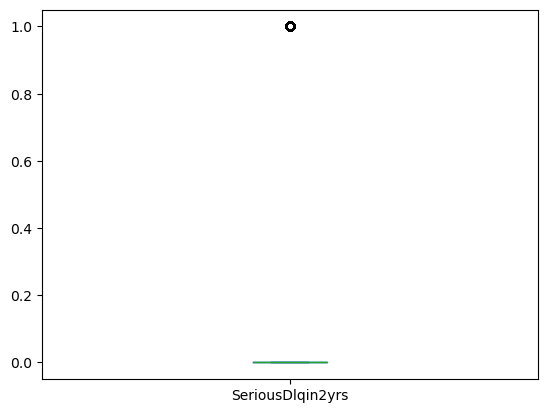

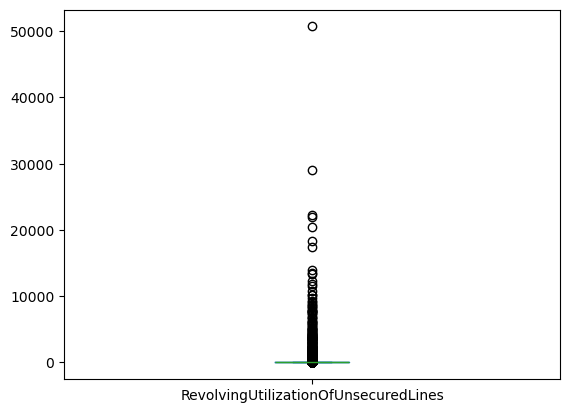

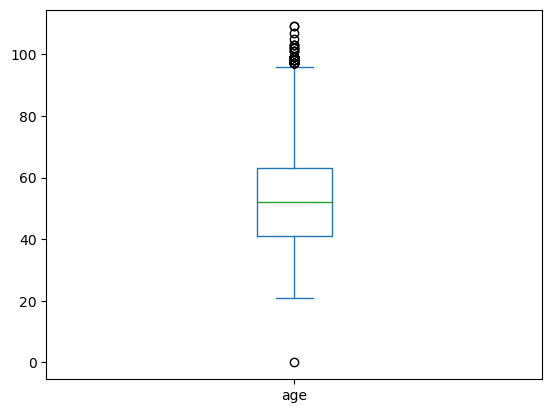

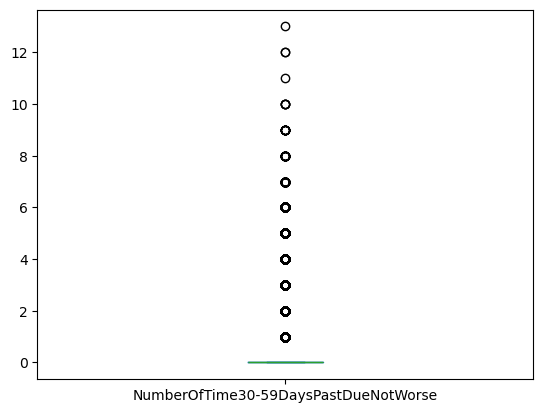

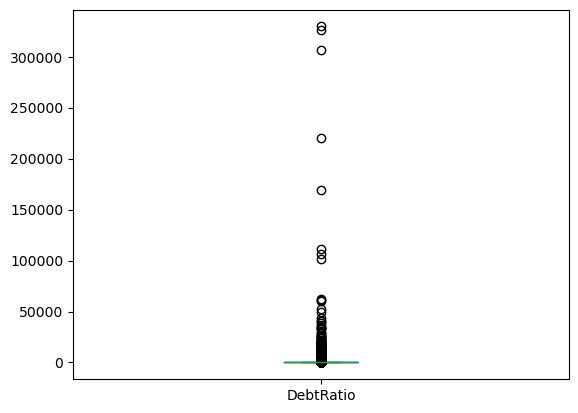

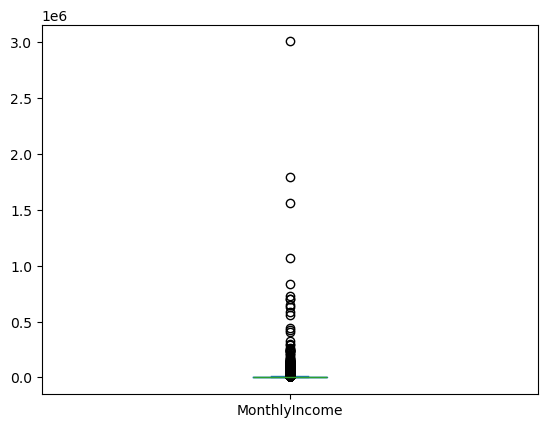

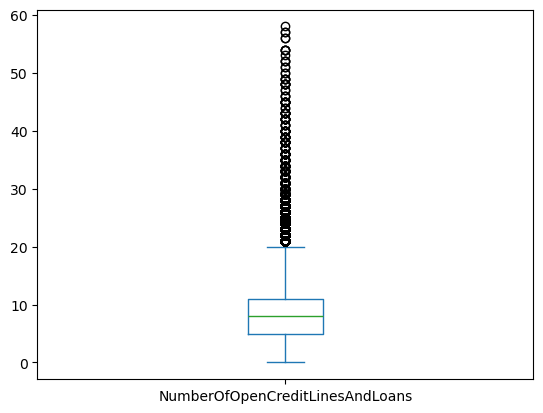

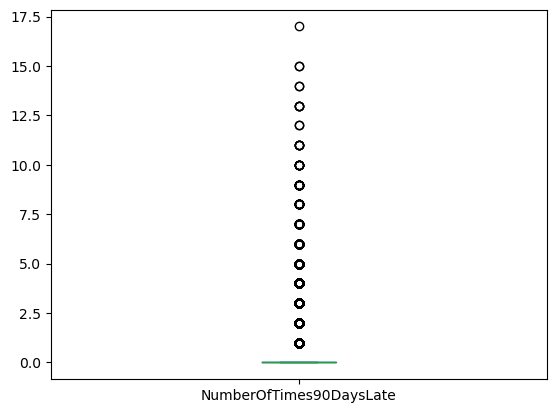

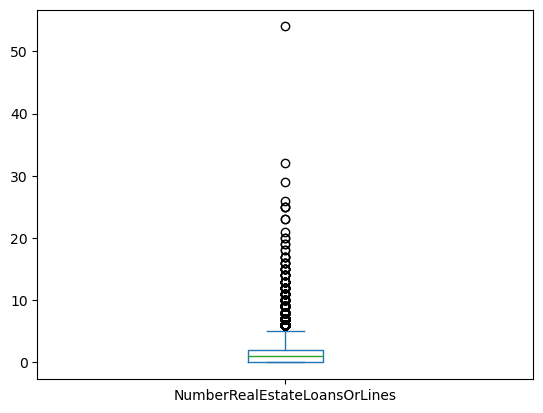

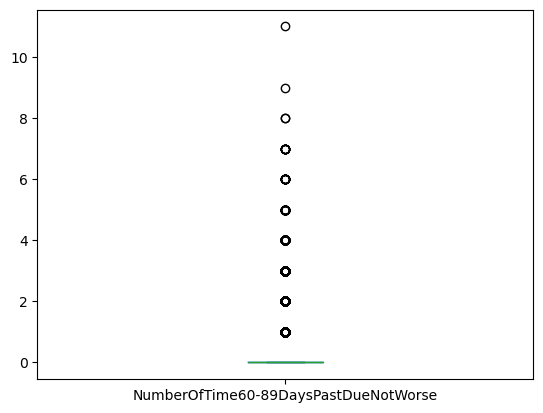

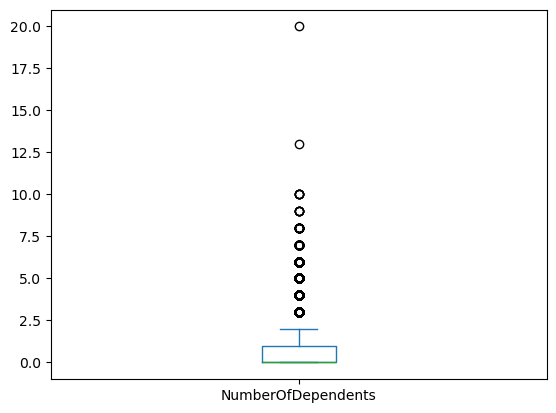

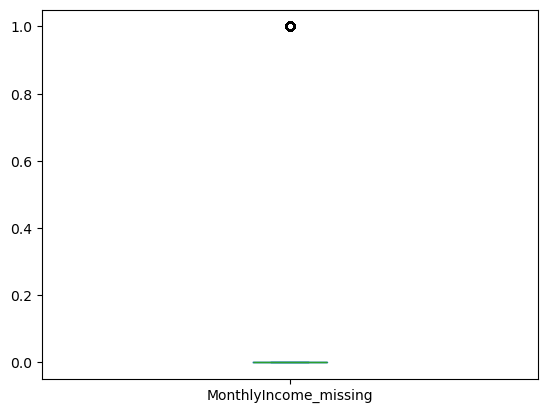

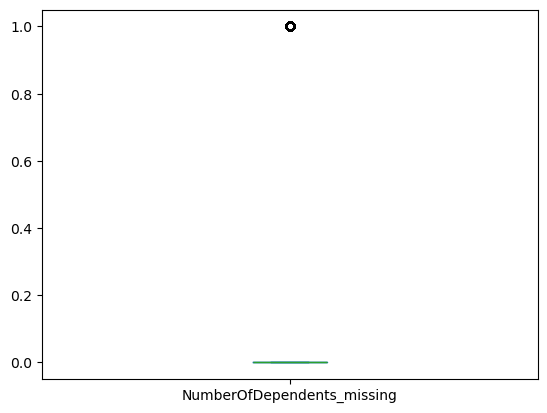

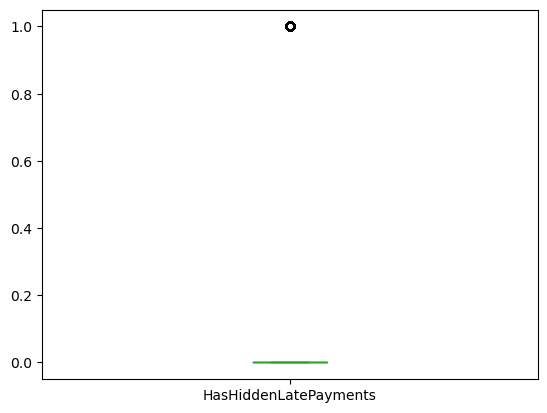

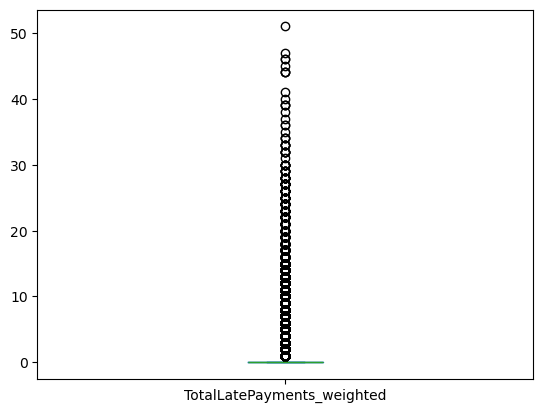

In [17]:
for col in df.columns:
    df[col].plot(kind='box')
    plt.show()

Для скошенных распределений лучше использовать Modefied Z-score с базовыми параметрами 0.6745  и порогом Mi > 3.5

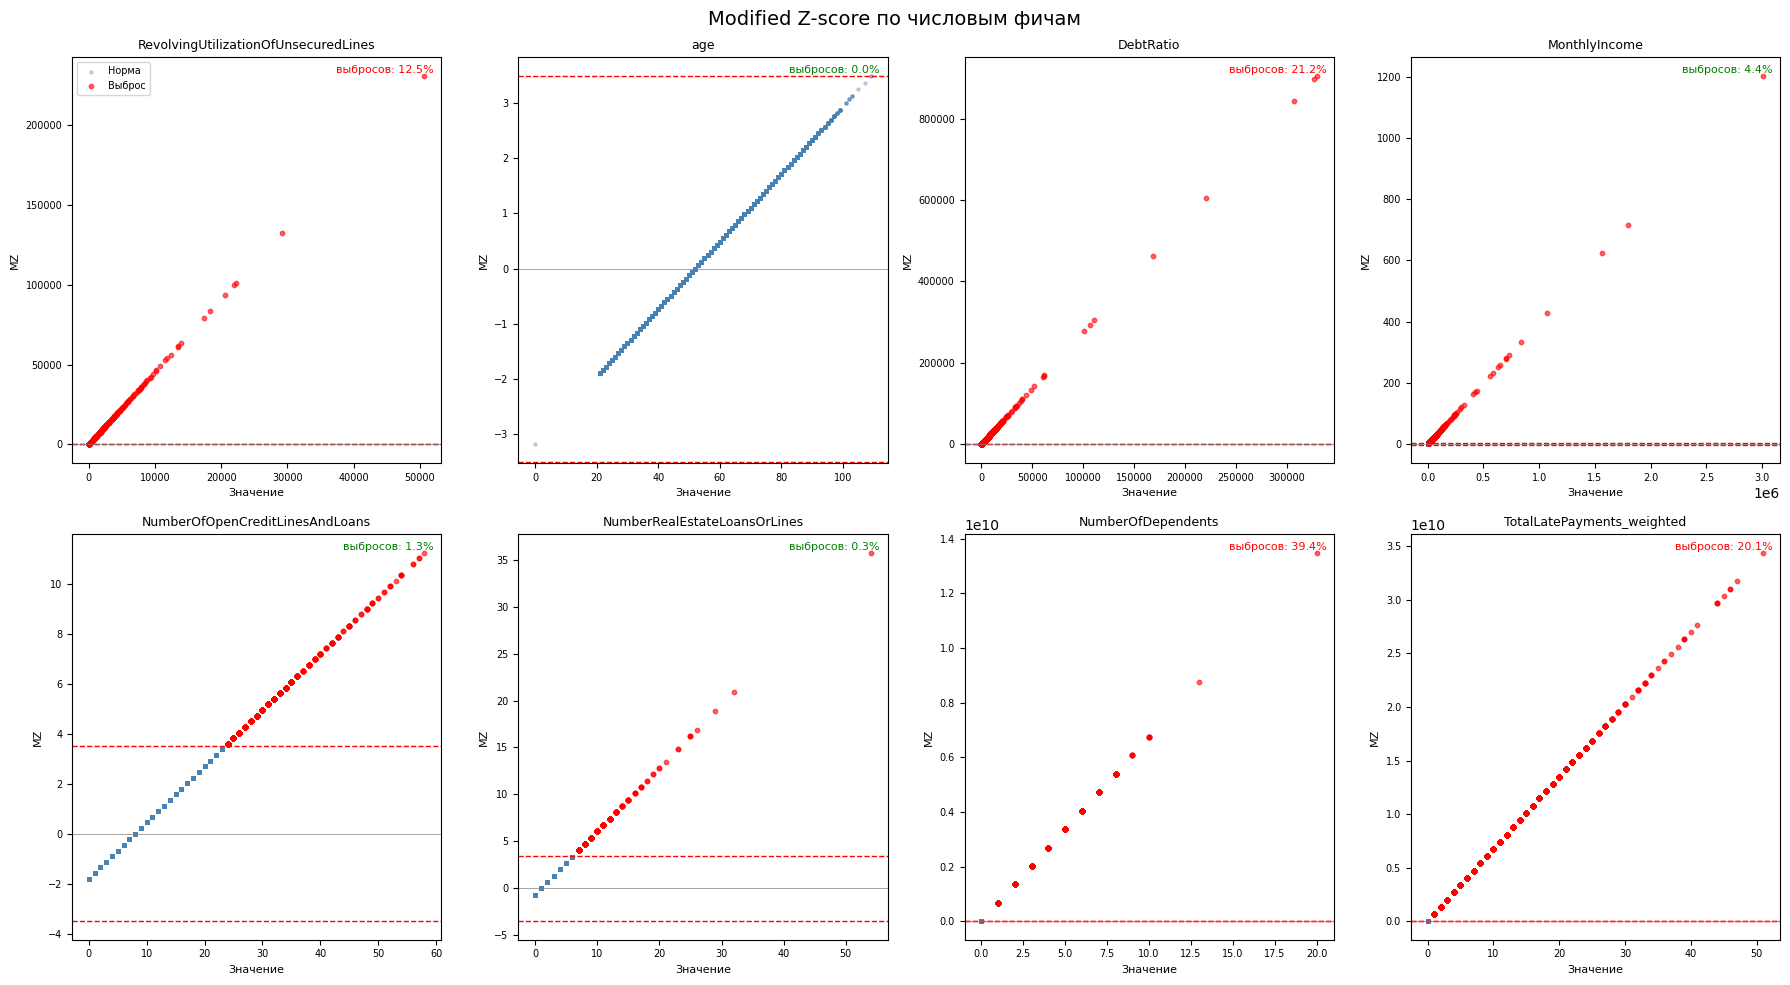

In [18]:
num_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents",
    "TotalLatePayments_weighted"
]

THRESHOLD = 3.5

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle("Modified Z-score по числовым фичам", fontsize=14)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]

    series = df[col].dropna().values

    # Считаем Modified Z-score
    med = np.median(series)
    mad = np.median(np.abs(series - med))
    mz  = 0.6745 * (series - med) / (mad + 1e-9)

    is_outlier = np.abs(mz) > THRESHOLD
    pct = is_outlier.mean() * 100

    # Scatter: исходное значение vs MZ
    ax.scatter(series[~is_outlier], mz[~is_outlier],
               color="steelblue", s=5, alpha=0.3, label="Норма")
    ax.scatter(series[is_outlier], mz[is_outlier],
               color="red", s=10, alpha=0.6, label="Выброс")

    # Линии порога
    ax.axhline(+THRESHOLD, color="red", linestyle="--", linewidth=1)
    ax.axhline(-THRESHOLD, color="red", linestyle="--", linewidth=1)
    ax.axhline(0, color="gray", linestyle="-", linewidth=0.5)

    ax.set_title(col, fontsize=9)
    ax.set_xlabel("Значение", fontsize=8)
    ax.set_ylabel("MZ", fontsize=8)
    ax.tick_params(labelsize=7)

    # Статистика в углу
    ax.text(0.98, 0.98, f"выбросов: {pct:.1f}%",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8, color="red" if pct > 5 else "green")

axes[0].legend(fontsize=7)

plt.tight_layout()
plt.show()

RevolvingUtilization \
  Основная прямая ниже пунктира (синие) \
  Резкий разрыв — красные точки далеко вверху \
  12.5% выбросов\
  → явные аномалии, значения до 50 000 при норме 0-1 

DebtRatio \
  Основная прямая почти горизонтальна у нуля \
  Красные точки улетают до 400 000+ \
  21.2% выбросов \
  → экстремальные выбросы, деление на 0 

NumberOfDependents \
  Почти ВСЕ точки красные (39.4%) \
  Прямая сразу уходит за пунктир \
  → MZ сломан: медиана=0, MAD=0 \
  → метод не применим 

In [19]:
df[df["RevolvingUtilizationOfUnsecuredLines"] > 0]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,NumberOfDependents_missing,HasHiddenLatePayments,TotalLatePayments_weighted
0,1,0.766127,45,2.0,0.802982,9120.0,13,0.0,6,0.0,2.0,0,0,0,2.0
1,0,0.957151,40,0.0,0.121876,2600.0,4,0.0,0,0.0,1.0,0,0,0,0.0
2,0,0.658180,38,1.0,0.085113,3042.0,2,1.0,0,0.0,0.0,0,0,0,4.0
3,0,0.233810,30,0.0,0.036050,3300.0,5,0.0,0,0.0,0.0,0,0,0,0.0
4,0,0.907239,49,1.0,0.024926,63588.0,7,0.0,1,0.0,0.0,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149994,0,0.385742,50,0.0,0.404293,3400.0,7,0.0,0,0.0,0.0,0,0,0,0.0
149995,0,0.040674,74,0.0,0.225131,2100.0,4,0.0,1,0.0,0.0,0,0,0,0.0
149996,0,0.299745,44,0.0,0.716562,5584.0,4,0.0,1,0.0,2.0,0,0,0,0.0
149997,0,0.246044,58,0.0,3870.000000,5400.0,18,0.0,1,0.0,0.0,1,0,0,0.0


In [20]:
mask = df["RevolvingUtilizationOfUnsecuredLines"] > 5

print(f"Количество: {df.sum()}")
# print(f"Процент от датасета: {df.mean()*100}%")

print(df.loc[mask, "RevolvingUtilizationOfUnsecuredLines"].describe())

print(f"\nДефолт среди > 5:  {df.loc[mask,  'SeriousDlqin2yrs'].mean():.4f}")
print(f"Дефолт среди <= 5: {df.loc[~mask, 'SeriousDlqin2yrs'].mean():.4f}")


Количество: SeriousDlqin2yrs                        1.002600e+04
RevolvingUtilizationOfUnsecuredLines    9.072657e+05
age                                     7.844281e+06
NumberOfTime30-59DaysPastDueNotWorse    3.680300e+04
DebtRatio                               5.295076e+07
MonthlyIncome                           9.627682e+08
NumberOfOpenCreditLinesAndLoans         1.267914e+06
NumberOfTimes90DaysLate                 1.354400e+04
NumberRealEstateLoansOrLines            1.527360e+05
NumberOfTime60-89DaysPastDueNotWorse    9.706000e+03
NumberOfDependents                      1.106120e+05
MonthlyIncome_missing                   2.973100e+04
NumberOfDependents_missing              3.924000e+03
HasHiddenLatePayments                   2.690000e+02
TotalLatePayments_weighted              9.684700e+04
dtype: float64
count      254.000000
mean      3381.930768
std       5051.880235
min          5.148736
25%        760.500000
50%       1899.000000
75%       3871.750000
max      50708.000000
Na

In [51]:
df["RevolvingUtilizationOfUnsecuredLines"] = (
    df["RevolvingUtilizationOfUnsecuredLines"].clip(upper=1)
)

# Проверка
print(df["RevolvingUtilizationOfUnsecuredLines"].max())   # → 1.0
print(df["RevolvingUtilizationOfUnsecuredLines"].describe())

1.0
count    150000.000000
mean          0.319196
std           0.349481
min           0.000000
25%           0.029867
50%           0.154181
75%           0.559046
max           1.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


<Axes: >

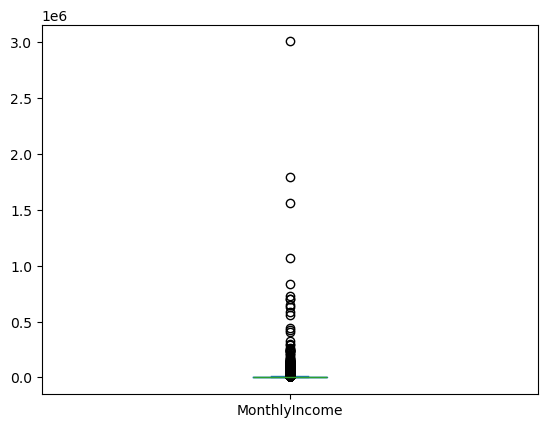

In [23]:
df["MonthlyIncome"].plot(kind='box')

<Axes: >

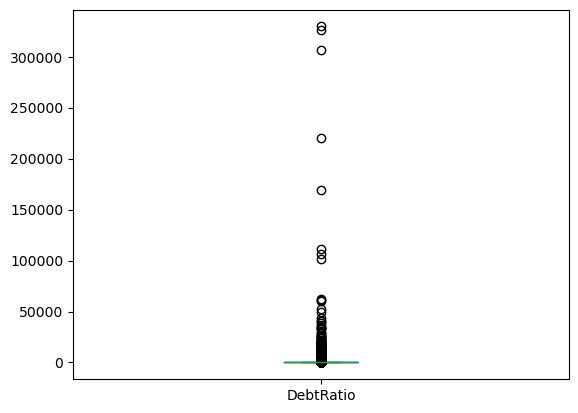

In [25]:
df["DebtRatio"].plot(kind='box')

Посмотрим какой доход у тех, кто имеет DebtRatio > 1000 (по умолчанию должен быть от 0 до 1)

In [28]:
mask = df["DebtRatio"] > 1000

print(f"\nMonthlyIncome у них:")
print(df.loc[mask, "MonthlyIncome"].value_counts().head())


MonthlyIncome у них:
MonthlyIncome
5400.0    15892
0.0         783
1.0         217
Name: count, dtype: int64


In [34]:
mask_0 = (df["DebtRatio"] > 1000) & (df["MonthlyIncome"] == 0)
mask_1 = (df["DebtRatio"] > 1000) & (df["MonthlyIncome"] == 1)

print("MonthlyIncome = 0")
print(f"Количество: {mask_0.sum()}")
print(f"Дефолт: {df.loc[mask_0, 'SeriousDlqin2yrs'].mean():.4f}")
print(df.loc[mask_0, ["DebtRatio", "MonthlyIncome", "age", "NumberOfDependents"]].describe())

print("\nMonthlyIncome = 1")
print(f"Количество: {mask_1.sum()}")
print(f"Дефолт: {df.loc[mask_1, 'SeriousDlqin2yrs'].mean():.4f}")
print(df.loc[mask_1, ["DebtRatio", "MonthlyIncome", "age", "NumberOfDependents"]].describe())


MonthlyIncome = 0
Количество: 783
Дефолт: 0.0485
          DebtRatio  MonthlyIncome         age  NumberOfDependents
count    783.000000          783.0  783.000000          783.000000
mean    2997.305236            0.0   50.173691            1.054917
std     3547.802837            0.0   12.012801            1.332574
min     1005.000000            0.0   24.000000            0.000000
25%     1556.000000            0.0   41.000000            0.000000
50%     2237.000000            0.0   48.000000            0.000000
75%     3265.000000            0.0   59.000000            2.000000
max    60212.000000            0.0   94.000000           10.000000

MonthlyIncome = 1
Количество: 217
Дефолт: 0.0369
          DebtRatio  MonthlyIncome         age  NumberOfDependents
count    217.000000          217.0  217.000000          217.000000
mean    2112.799539            1.0   49.027650            1.271889
std     4136.458885            0.0   10.598706            1.241561
min     1004.000000           

In [33]:
print("Средний возраст при income=0:", df.loc[mask_0, "age"].mean())
print("Средний возраст при income=1:", df.loc[mask_1, "age"].mean())
print("Средний возраст по датасету: ", df["age"].mean())

# Смотрим иждивенцев — если есть → скорее семья с одним кормильцем
print("\nИждивенцы при income=0:", df.loc[mask_0, "NumberOfDependents"].mean())
print("Иждивенцы при income=1:", df.loc[mask_1, "NumberOfDependents"].mean())


Средний возраст при income=0: 50.17369093231162
Средний возраст при income=1: 49.02764976958525
Средний возраст по датасету:  52.295206666666665

Иждивенцы при income=0: 1.0549169859514687
Иждивенцы при income=1: 1.271889400921659


Обе группы имеют дефолт НИЖЕ среднего:

  income = 0  →  дефолт 4.85%  vs  среднее 6.7%
  income = 1  →  дефолт 3.69%  vs  среднее 6.7%

Это значит:
  → это НЕ проблемные клиенты
  → это скорее состоятельные люди без официального дохода
  → или технические артефакты базы данных
  → DebtRatio огромный потому что деление на 0 или на 1

In [38]:
# income = 1 — заменяем на NaN (технический артефакт)
df.loc[df["MonthlyIncome"] == 1, "MonthlyIncome"] = np.nan
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(
    df["MonthlyIncome"].median()
)

# DebtRatio для обоих — clip по p99
# DebtRatio огромный из-за деления на 0/1, не несёт реального смысла
p99 = df["DebtRatio"].quantile(0.99)
print(f"DebtRatio p99: {p99:.2f}")
df["DebtRatio"] = df["DebtRatio"].clip(upper=p99)

DebtRatio p99: 4979.04


<Axes: >

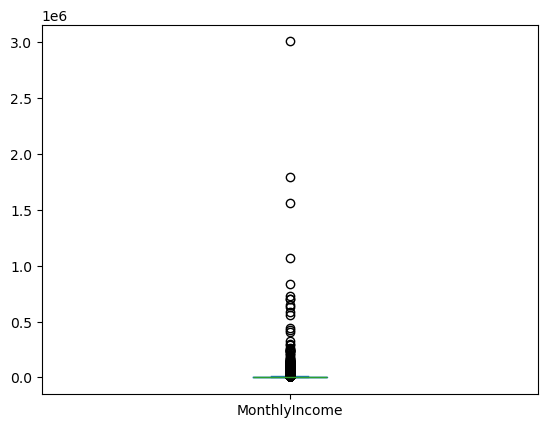

In [39]:
df["MonthlyIncome"].plot(kind='box')

<Axes: >

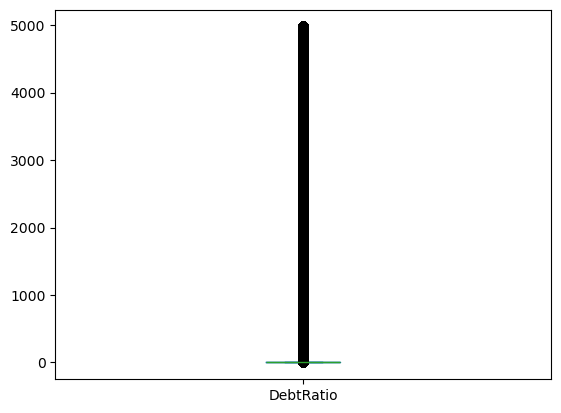

In [40]:
df["DebtRatio"].plot(kind='box')

In [42]:
mask_rich = df["MonthlyIncome"] > df["MonthlyIncome"].quantile(0.99)
print(df.loc[mask_rich,  "SeriousDlqin2yrs"].mean())
print(df.loc[~mask_rich, "SeriousDlqin2yrs"].mean())

0.054036024016010674
0.06696924599834345


Проверим дубликаты: 

In [43]:
n_full = df.duplicated().sum()
print(f"Полных дубликатов: {n_full}")

# orig_cols = [
#     "RevolvingUtilizationOfUnsecuredLines",
#     "age",
#     "DebtRatio",
#     "MonthlyIncome",
#     "NumberOfOpenCreditLinesAndLoans",
#     "NumberRealEstateLoansOrLines",
#     "NumberOfDependents"
# ]

orig_cols = df.columns

n_orig = df.duplicated(subset=orig_cols).sum()
print(f"Дубликатов по оригинальным фичам: {n_orig}")

# Смотрим дефолт у дубликатов
dup_mask = df.duplicated(subset=orig_cols, keep=False)
print(f"\nДефолт у дубликатов:      {df.loc[dup_mask,  'SeriousDlqin2yrs'].mean():.4f}")
print(f"Дефолт у уникальных:      {df.loc[~dup_mask, 'SeriousDlqin2yrs'].mean():.4f}")


Полных дубликатов: 610
Дубликатов по оригинальным фичам: 610

Дефолт у дубликатов:      0.0333
Дефолт у уникальных:      0.0671


In [44]:
df = df.drop_duplicates(keep="first")

In [45]:
print(f"Размер после удаления: {df.shape}")


Размер после удаления: (149390, 15)


WoE & IV analysis

In [46]:
def calc_woe_iv(df, feature, target, bins=10):
    # Разбиваем на бакеты
    df = df[[feature, target]].copy().dropna()
    df["bucket"] = pd.qcut(df[feature], q=bins, duplicates="drop")

    grouped = df.groupby("bucket")[target].agg(["sum", "count"])
    grouped.columns = ["defaults", "total"]
    grouped["non_defaults"] = grouped["total"] - grouped["defaults"]

    total_def     = grouped["defaults"].sum()
    total_non_def = grouped["non_defaults"].sum()


    grouped["pct_def"]     = grouped["defaults"]     / total_def
    grouped["pct_non_def"] = grouped["non_defaults"] / total_non_def

    # WoE и IV
    grouped["WoE"] = np.log(grouped["pct_non_def"] / grouped["pct_def"])
    grouped["IV"]  = (grouped["pct_non_def"] - grouped["pct_def"]) * grouped["WoE"]

    iv_total = grouped["IV"].sum()
    return grouped, iv_total

In [47]:
num_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents",
    "TotalLatePayments_weighted"
]

iv_results = {}
for col in num_cols:
    _, iv = calc_woe_iv(df, col, "SeriousDlqin2yrs")
    iv_results[col] = iv

# Сортируем по IV
iv_df = pd.Series(iv_results).sort_values(ascending=False)
print(iv_df)

TotalLatePayments_weighted              1.225468
RevolvingUtilizationOfUnsecuredLines    1.119016
age                                     0.258423
DebtRatio                               0.073569
NumberOfOpenCreditLinesAndLoans         0.070970
MonthlyIncome                           0.069980
NumberOfDependents                      0.024616
NumberRealEstateLoansOrLines            0.012259
dtype: float64


/var/folders/0w/pg719rr9519435t25t6yf2hm0000gn/T/ipykernel_20449/2270524923.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bucket")[target].agg(["sum", "count"])
/var/folders/0w/pg719rr9519435t25t6yf2hm0000gn/T/ipykernel_20449/2270524923.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bucket")[target].agg(["sum", "count"])
/var/folders/0w/pg719rr9519435t25t6yf2hm0000gn/T/ipykernel_20449/2270524923.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current 

/var/folders/0w/pg719rr9519435t25t6yf2hm0000gn/T/ipykernel_20449/2270524923.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bucket")[target].agg(["sum", "count"])


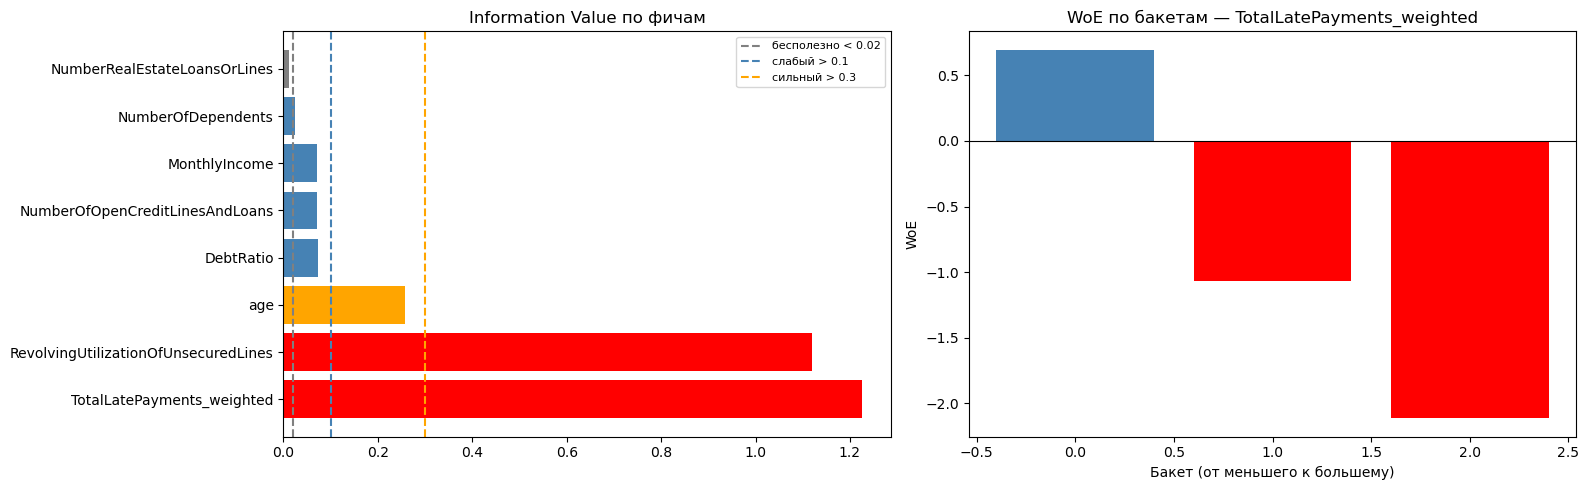

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# График 1 — IV по фичам
colors = []
for v in iv_df.values:
    if v < 0.02:
        colors.append("gray")
    elif v < 0.1:
        colors.append("steelblue")
    elif v < 0.3:
        colors.append("orange")
    else:
        colors.append("red")

axes[0].barh(iv_df.index, iv_df.values, color=colors)
axes[0].axvline(0.02, color="gray",   linestyle="--", label="бесполезно < 0.02")
axes[0].axvline(0.1,  color="steelblue", linestyle="--", label="слабый > 0.1")
axes[0].axvline(0.3,  color="orange", linestyle="--", label="сильный > 0.3")
axes[0].set_title("Information Value по фичам")
axes[0].legend(fontsize=8)

best_col = iv_df.index[0]
woe_df, _ = calc_woe_iv(df, best_col, "SeriousDlqin2yrs")

axes[1].bar(range(len(woe_df)), woe_df["WoE"],
            color=["red" if w < 0 else "steelblue" for w in woe_df["WoE"]])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title(f"WoE по бакетам — {best_col}")
axes[1].set_xlabel("Бакет (от меньшего к большему)")
axes[1].set_ylabel("WoE")

plt.tight_layout()
plt.show()

1. TotalLatePayments и Revolving — два главных предиктора
   Модель будет опираться именно на них

2. NumberRealEstateLoansOrLines — можно удалить
   IV < 0.02, почти не несёт информации

3. NumberOfDependents — на грани
   IV ≈ 0.02, оставить только флаг который мы создали

4. IV > 0.5 у двух фичей — проверь нет ли утечки данных!
   TotalLatePayments = мы сами создали из просрочек
   Revolving = оригинальная фича

   TotalLatePayments логично имеет высокий IV —
   просрочки напрямую связаны с дефолтом, это нормально

In [52]:
# Проверяем перед удалением
print(df["NumberRealEstateLoansOrLines"].value_counts().head())
print(f"Дефолт = 0 loans: {df.loc[df['NumberRealEstateLoansOrLines']==0, 'SeriousDlqin2yrs'].mean():.4f}")
print(f"Дефолт > 0 loans: {df.loc[df['NumberRealEstateLoansOrLines']>0,  'SeriousDlqin2yrs'].mean():.4f}")

# Если разницы нет — удаляем
# df.drop(columns=["NumberRealEstateLoansOrLines"], inplace=True)

NumberRealEstateLoansOrLines
0    55579
1    52338
2    31522
3     6299
4     2170
Name: count, dtype: int64
Дефолт = 0 loans: 0.0838
Дефолт > 0 loans: 0.0571


In [54]:
print(df.groupby("NumberRealEstateLoansOrLines")["SeriousDlqin2yrs"].mean())


NumberRealEstateLoansOrLines
0     0.083755
1     0.052505
2     0.055993
3     0.066995
4     0.089401
5     0.120464
6     0.150000
7     0.181287
8     0.247312
9     0.179487
10    0.135135
11    0.086957
12    0.333333
13    0.333333
14    0.000000
15    0.428571
16    0.250000
17    0.250000
18    0.000000
19    0.000000
20    0.500000
21    0.000000
23    0.000000
25    0.333333
26    0.000000
29    1.000000
32    0.000000
54    0.000000
Name: SeriousDlqin2yrs, dtype: float64


Сохраним трейн в разные датасеты - 1 для бейзлайн моделей, второй для трансформеров

In [55]:
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'MonthlyIncome_missing',
       'NumberOfDependents_missing', 'HasHiddenLatePayments',
       'TotalLatePayments_weighted'],
      dtype='object')

In [56]:
df.to_csv("train_give_me_credit_baseline.csv")

In [58]:
fe_cols = [
    "TotalLatePayments_weighted",
    "HasHiddenLatePayments",
    "MonthlyIncome_missing",
    "NumberOfDependents_missing",
    "Revolving_over_limit"
]

df_transformer = df.drop(
    columns=[c for c in fe_cols if c in df.columns]
)

# Проверка
print(f"Baseline колонки:     {df.columns.tolist()}")
print(f"Transformer колонки:  {df_transformer.columns.tolist()}")

Baseline колонки:     ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'MonthlyIncome_missing', 'NumberOfDependents_missing', 'HasHiddenLatePayments', 'TotalLatePayments_weighted']
Transformer колонки:  ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [59]:
df_transformer.to_csv("train_give_me_credit_transformer.csv")